In [40]:
import numpy as np
import torch
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms
import torch.nn.functional as F


class LunaSingleSampleLoader:
    def __init__(self, img_size=512, is_transform=True):
        self.img_size = img_size
        self.is_transform = is_transform

        # Same transforms as your Dataset
        self.img_tf = transforms.Compose([
            transforms.Resize(self.img_size),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[-464.62011798179316],
                std=[444.2257740178454]
            )
        ])

        self.label_tf = transforms.Compose([
            transforms.Resize(self.img_size, interpolation=Image.NEAREST),
            transforms.ToTensor(),
        ])

    def load(self, image_path, label_path):
        """
        Loads a single image + label, applies transforms,
        and returns tensors ready for the model.
        """

        # Load .npy files
        img_np = np.load(image_path).astype(float)  # 
        print(f"Original image shape: {img_np.shape}")
        img_np = img_np[0, :, :]
        print(f"Image shape: {img_np.shape}")

        label_np = np.load(label_path)

        # Convert to PIL
        img = Image.fromarray(img_np)
        label = Image.fromarray(label_np)

        if self.is_transform:
            img = self.img_tf(img)
            label = self.label_tf(label)

        # Remove channel dimension from label (C=1)
        label = label.squeeze(0)

        return img, label


In [41]:
def visualize_image_and_label(img_tensor, label_tensor):
    """
    img_tensor: (1, H, W) normalized
    label_tensor: (H, W)
    """

    # Undo normalization for visualization
    mean = -464.62011798179316
    std = 444.2257740178454

    img_vis = img_tensor.clone()
    img_vis = img_vis * std + mean
    img_vis = img_vis.squeeze().cpu().numpy()

    label_vis = label_tensor.cpu().numpy()

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].imshow(img_vis, cmap="gray")
    axes[0].set_title("Input Image")
    axes[0].axis("off")

    axes[1].imshow(label_vis, cmap="gray")
    axes[1].set_title("Label / Mask")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()


Original image shape: (3, 512, 512)
Image shape: (512, 512)
Label shape: torch.Size([512, 512])


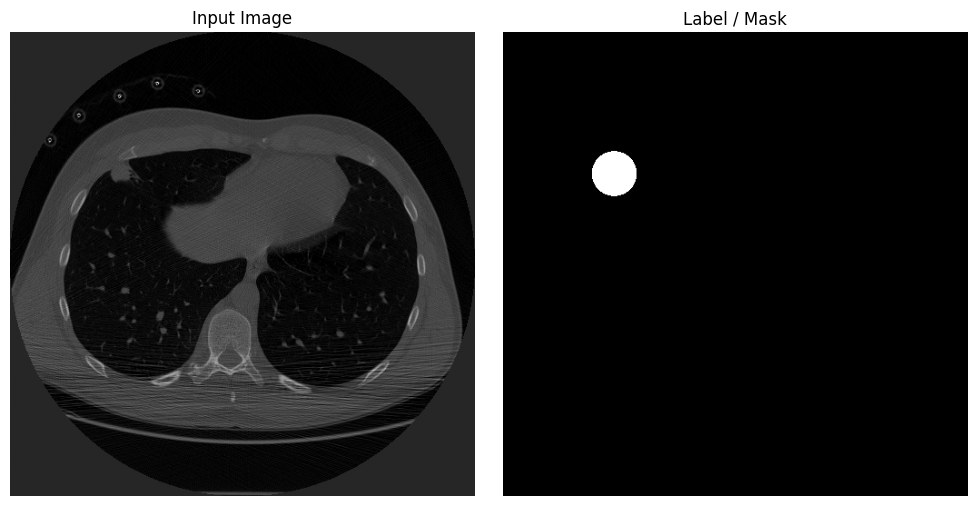

In [44]:
loader = LunaSingleSampleLoader(img_size=512)

img, label = loader.load(
    image_path=r"C:\Minh\K1_2025\Neuron Network\Project\samples\train\images\images_0.npy",
    label_path=r"C:\Minh\K1_2025\Neuron Network\Project\samples\train\labels\masks_0.npy"
)

# print("Image shape:", img.shape)     # (1, 512, 512)
print("Label shape:", label.shape)   # (512, 512)

visualize_image_and_label(img, label)


#  Unet

In [45]:
import segmentation_models_pytorch as smp

In [29]:
# Load model
unet_path = r"C:\Minh\K1_2025\Neuron Network\Project\weights\Unet\Adam_1e-4_ep100_CE+Lov"

n_classes = 2
net_in_channels = 1

net = smp.Unet(
    encoder_name="resnet34",        # choose encoder, e.g. mobilenet_v2 or efficientnet-b7
    encoder_weights="imagenet",     # use `imagenet` pre-trained weights for encoder initialization
    in_channels=net_in_channels,                  # model input channels (1 for gray-scale images, 3 for RGB, etc.)
    classes=n_classes,                      # model output channels (number of classes in your dataset)
)

net.load_state_dict(torch.load(unet_path + '\sumnet_best.pt', map_location=torch.device('cpu')))  # Load to cpu instead of GPU
if torch.cuda.is_available():
    net = net.cuda()
net.eval()

<>:14: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:14: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\CASPER\AppData\Local\Temp\ipykernel_24572\295332270.py:14: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  net.load_state_dict(torch.load(unet_path + '\sumnet_best.pt', map_location=torch.device('cpu')))  # Load to cpu instead of GPU


Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

In [46]:
# Inderecne to get the prediction

img_slice_norm = img.unsqueeze(0)
print(f"Input tensor shape for model: {img_slice_norm.shape}")  # (1, 1, 512, 512)

Input tensor shape for model: torch.Size([1, 1, 512, 512])


In [47]:
with torch.no_grad():
    out = F.softmax(net(img_slice_norm), dim=1)

out_np = np.asarray(
    out[0, 1].detach().cpu().numpy() * 255,
    dtype=np.uint8
)

In [48]:
import numpy as np
import matplotlib.pyplot as plt


def visualize_triple_overlay(
    img_tensor,
    pred_mask,
    gt_mask,
    mean=-464.62011798179316,
    std=444.2257740178454,
    pred_thresh=128
):
    """
    img_tensor: torch.Tensor (1, H, W) normalized
    pred_mask: np.ndarray (H, W) uint8 [0,255]
    gt_mask: torch.Tensor or np.ndarray (H, W) {0,1}
    """

    # --- Convert image back to numpy (unnormalize) ---
    img_np = img_tensor.squeeze().cpu().numpy()
    img_np = img_np * std + mean
    img_np = np.clip(img_np, img_np.min(), img_np.max())

    # --- Normalize image to [0,1] for display ---
    img_norm = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)

    # --- Prepare masks ---
    pred_bin = (pred_mask > pred_thresh).astype(np.uint8)
    gt_bin = gt_mask.cpu().numpy() if hasattr(gt_mask, "cpu") else gt_mask
    gt_bin = (gt_bin > 0).astype(np.uint8)

    H, W = img_norm.shape

    # --- RGB overlay ---
    overlay = np.stack([img_norm]*3, axis=-1)

    # True Positive → Green
    tp = (pred_bin == 1) & (gt_bin == 1)
    overlay[tp] = [0, 1, 0]

    # False Positive → Red
    fp = (pred_bin == 1) & (gt_bin == 0)
    overlay[fp] = [1, 0, 0]

    # False Negative → Yellow
    fn = (pred_bin == 0) & (gt_bin == 1)
    overlay[fn] = [1, 1, 0]

    # --- Plot ---
    plt.figure(figsize=(6, 6))
    plt.imshow(overlay)
    plt.title("Overlay: Green=TP | Red=FP | Yellow=FN")
    plt.axis("off")
    plt.tight_layout()
    plt.show()


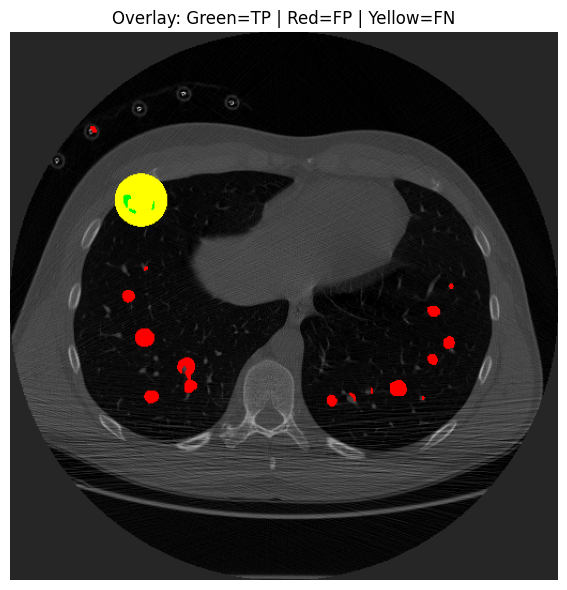

In [49]:
visualize_triple_overlay(
    img,
    out_np,
    label
)